In [54]:
import os
import pandas as pd
import missingno as ms

import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv


In [22]:
import warnings
warnings.filterwarnings("ignore")

In [53]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Stock Portfolio Performance Optimization")

In [ ]:
from src.features import Calculations

In [3]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Stock Portfolio Performance Optimization/data/raw")

In [4]:
portfolio_data = pd.read_csv("Portfolio_data.csv")
portfolio_data.head()

,AAPL,Date_AAPL,MSFT,Date_MSFT,AMZN,Date_AMZN,TSLA,Date_TSLA,GOOGL,Date_GOOGL,META,Date_META,NVDA,Date_NVDA,JPM,Date_JPM,WMT,Date_WMT,NFLX,Date_NFLX
0,126.366859,2021-06-15,247.947250,2021-06-15,169.156494,2021-06-15,199.786667,2021-06-15,120.352303,2021-06-15,334.127930,2021-06-15,17.727182,2021-06-15,136.760559,2021-06-15,43.781265,2021-06-15,49.189999,2021-06-15
1,126.863953,2021-06-16,247.006790,2021-06-16,170.762497,2021-06-16,201.623337,2021-06-16,119.710999,2021-06-16,328.502014,2021-06-16,17.748856,2021-06-16,137.721207,2021-06-16,42.890003,2021-06-16,49.241001,2021-06-16
2,128.462570,2021-06-17,250.384857,2021-06-17,174.462006,2021-06-17,205.533340,2021-06-17,120.673477,2021-06-17,333.889832,2021-06-17,18.592939,2021-06-17,133.746521,2021-06-17,43.068253,2021-06-17,49.834000,2021-06-17
3,127.166130,2021-06-18,248.974106,2021-06-18,174.345001,2021-06-18,207.770004,2021-06-18,119.055313,2021-06-18,327.093170,2021-06-18,18.574503,2021-06-18,130.362320,2021-06-18,42.270802,2021-06-18,50.077000,2021-06-18
4,128.959671,2021-06-21,252.045166,2021-06-21,172.697998,2021-06-21,206.943329,2021-06-21,120.741852,2021-06-21,329.702637,2021-06-21,18.363735,2021-06-21,132.574417,2021-06-21,42.655457,2021-06-21,49.700001,2021-06-21


In [7]:
portfolio_data.size
portfolio_data.shape

(1255, 20)

In [8]:
portfolio_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   AAPL        1255 non-null   float64
 1   Date_AAPL   1255 non-null   object 
 2   MSFT        1255 non-null   float64
 3   Date_MSFT   1255 non-null   object 
 4   AMZN        1255 non-null   float64
 5   Date_AMZN   1255 non-null   object 
 6   TSLA        1255 non-null   float64
 7   Date_TSLA   1255 non-null   object 
 8   GOOGL       1255 non-null   float64
 9   Date_GOOGL  1255 non-null   object 
 10  META        1255 non-null   float64
 11  Date_META   1255 non-null   object 
 12  NVDA        1255 non-null   float64
 13  Date_NVDA   1255 non-null   object 
 14  JPM         1255 non-null   float64
 15  Date_JPM    1255 non-null   object 
 16  WMT         1255 non-null   float64
 17  Date_WMT    1255 non-null   object 
 18  NFLX        1255 non-null   float64
 19  Date_NFLX   1255 non-null  

In [13]:
portfolio_data[portfolio_data.duplicated()]

,AAPL,Date_AAPL,MSFT,Date_MSFT,AMZN,Date_AMZN,TSLA,Date_TSLA,GOOGL,Date_GOOGL,META,Date_META,NVDA,Date_NVDA,JPM,Date_JPM,WMT,Date_WMT,NFLX,Date_NFLX


In [15]:
date_cols = portfolio_data.select_dtypes(include = "object").columns 
for col in date_cols:
    portfolio_data[col] = pd.to_datetime(portfolio_data[col])

In [17]:
portfolio_data.head()

,AAPL,Date_AAPL,MSFT,Date_MSFT,AMZN,Date_AMZN,TSLA,Date_TSLA,GOOGL,Date_GOOGL,META,Date_META,NVDA,Date_NVDA,JPM,Date_JPM,WMT,Date_WMT,NFLX,Date_NFLX
0,126.366859,2021-06-15,247.947250,2021-06-15,169.156494,2021-06-15,199.786667,2021-06-15,120.352303,2021-06-15,334.127930,2021-06-15,17.727182,2021-06-15,136.760559,2021-06-15,43.781265,2021-06-15,49.189999,2021-06-15
1,126.863953,2021-06-16,247.006790,2021-06-16,170.762497,2021-06-16,201.623337,2021-06-16,119.710999,2021-06-16,328.502014,2021-06-16,17.748856,2021-06-16,137.721207,2021-06-16,42.890003,2021-06-16,49.241001,2021-06-16
2,128.462570,2021-06-17,250.384857,2021-06-17,174.462006,2021-06-17,205.533340,2021-06-17,120.673477,2021-06-17,333.889832,2021-06-17,18.592939,2021-06-17,133.746521,2021-06-17,43.068253,2021-06-17,49.834000,2021-06-17
3,127.166130,2021-06-18,248.974106,2021-06-18,174.345001,2021-06-18,207.770004,2021-06-18,119.055313,2021-06-18,327.093170,2021-06-18,18.574503,2021-06-18,130.362320,2021-06-18,42.270802,2021-06-18,50.077000,2021-06-18
4,128.959671,2021-06-21,252.045166,2021-06-21,172.697998,2021-06-21,206.943329,2021-06-21,120.741852,2021-06-21,329.702637,2021-06-21,18.363735,2021-06-21,132.574417,2021-06-21,42.655457,2021-06-21,49.700001,2021-06-21


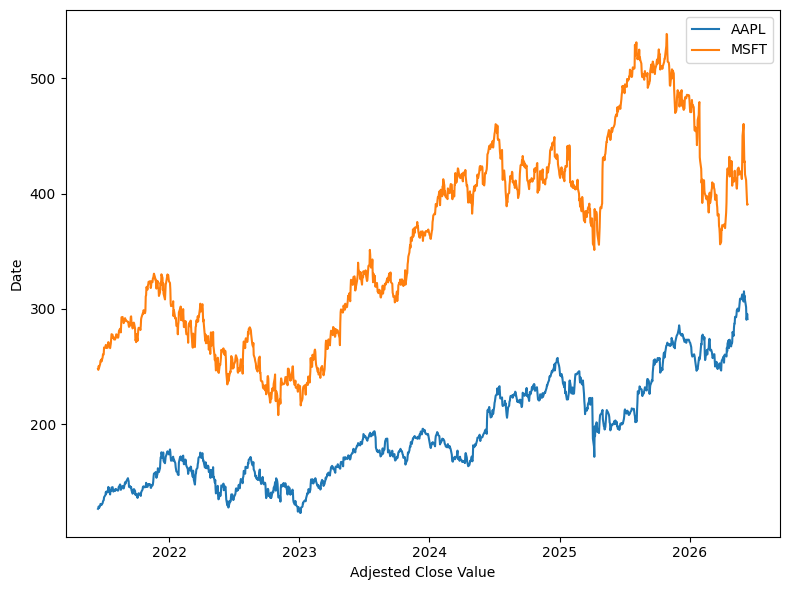

In [33]:
num_cols = portfolio_data.select_dtypes(include = "float64").columns 
plt.figure(figsize = (8, 6))

for col in num_cols[:2]:
    plt.plot(portfolio_data[f"Date_{col}"], portfolio_data[col] , label = col)
plt.xlabel("Adjested Close Value")
plt.ylabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

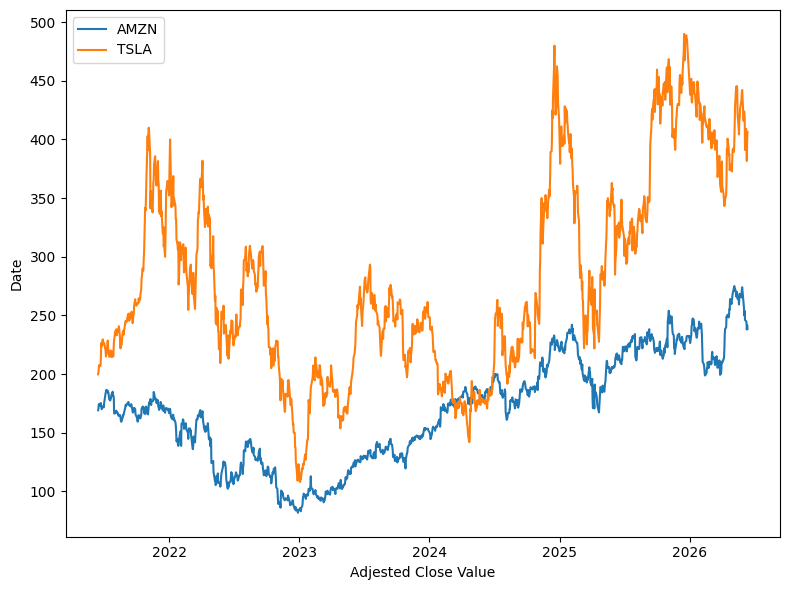

In [34]:
num_cols = portfolio_data.select_dtypes(include = "float64").columns 
plt.figure(figsize = (8, 6))

for col in num_cols[2:4]:
    plt.plot(portfolio_data[f"Date_{col}"], portfolio_data[col] , label = col)
plt.xlabel("Adjested Close Value")
plt.ylabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

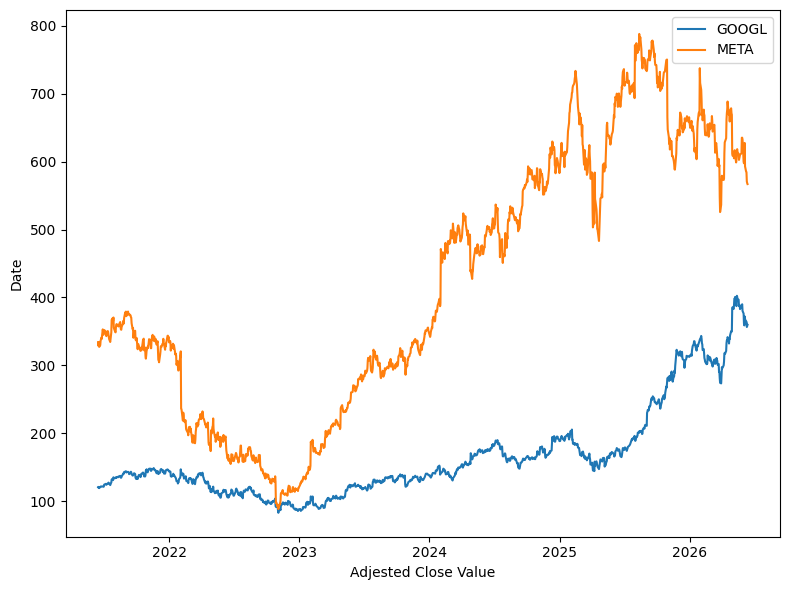

In [35]:
num_cols = portfolio_data.select_dtypes(include = "float64").columns 
plt.figure(figsize = (8, 6))

for col in num_cols[4:6]:
    plt.plot(portfolio_data[f"Date_{col}"], portfolio_data[col] , label = col)
plt.xlabel("Adjested Close Value")
plt.ylabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

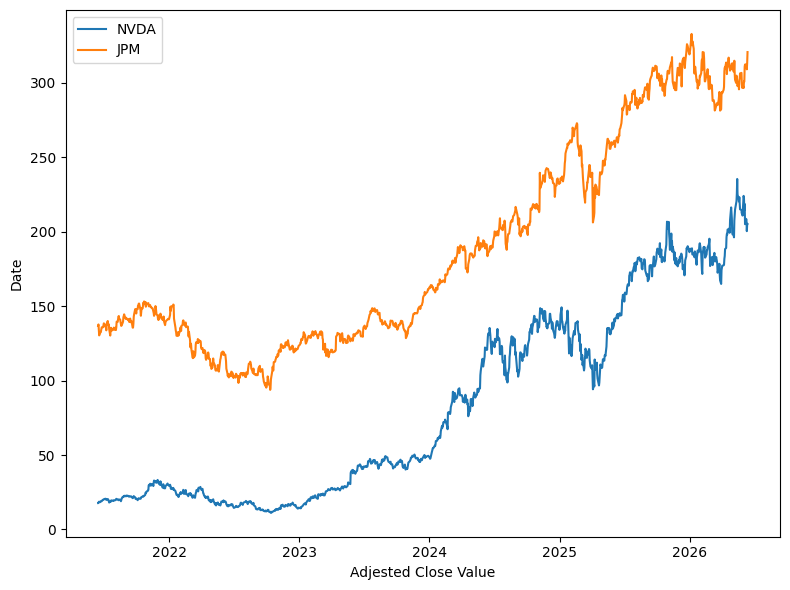

In [36]:
num_cols = portfolio_data.select_dtypes(include = "float64").columns 
plt.figure(figsize = (8, 6))

for col in num_cols[6:8]:
    plt.plot(portfolio_data[f"Date_{col}"], portfolio_data[col] , label = col)
plt.xlabel("Adjested Close Value")
plt.ylabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

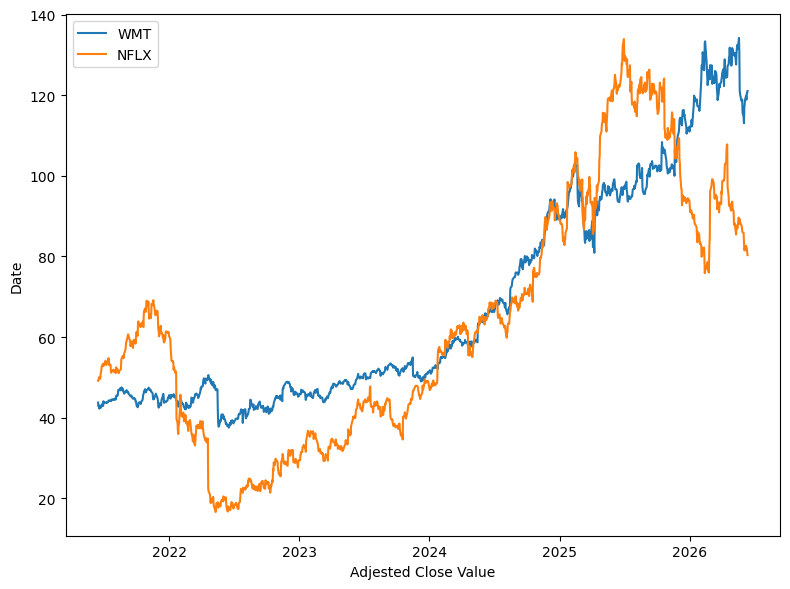

In [37]:
num_cols = portfolio_data.select_dtypes(include = "float64").columns 
plt.figure(figsize = (8, 6))

for col in num_cols[8:]:
    plt.plot(portfolio_data[f"Date_{col}"], portfolio_data[col] , label = col)
plt.xlabel("Adjested Close Value")
plt.ylabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
portfolio_data.head()

,AAPL,Date_AAPL,MSFT,Date_MSFT,AMZN,Date_AMZN,TSLA,Date_TSLA,GOOGL,Date_GOOGL,META,Date_META,NVDA,Date_NVDA,JPM,Date_JPM,WMT,Date_WMT,NFLX,Date_NFLX
0,126.366859,2021-06-15,247.947250,2021-06-15,169.156494,2021-06-15,199.786667,2021-06-15,120.352303,2021-06-15,334.127930,2021-06-15,17.727182,2021-06-15,136.760559,2021-06-15,43.781265,2021-06-15,49.189999,2021-06-15
1,126.863953,2021-06-16,247.006790,2021-06-16,170.762497,2021-06-16,201.623337,2021-06-16,119.710999,2021-06-16,328.502014,2021-06-16,17.748856,2021-06-16,137.721207,2021-06-16,42.890003,2021-06-16,49.241001,2021-06-16
2,128.462570,2021-06-17,250.384857,2021-06-17,174.462006,2021-06-17,205.533340,2021-06-17,120.673477,2021-06-17,333.889832,2021-06-17,18.592939,2021-06-17,133.746521,2021-06-17,43.068253,2021-06-17,49.834000,2021-06-17
3,127.166130,2021-06-18,248.974106,2021-06-18,174.345001,2021-06-18,207.770004,2021-06-18,119.055313,2021-06-18,327.093170,2021-06-18,18.574503,2021-06-18,130.362320,2021-06-18,42.270802,2021-06-18,50.077000,2021-06-18
4,128.959671,2021-06-21,252.045166,2021-06-21,172.697998,2021-06-21,206.943329,2021-06-21,120.741852,2021-06-21,329.702637,2021-06-21,18.363735,2021-06-21,132.574417,2021-06-21,42.655457,2021-06-21,49.700001,2021-06-21


In [43]:
apple_data = portfolio_data[["Date_AAPL", "AAPL"]]
apple_data = apple_data.set_index("Date_AAPL")
monthly_data = apple_data.resample("M").sum()

In [45]:
monthly_data.head(6)

,AAPL
Date_AAPL,
2021-06-30,1556.298691
2021-07-31,2970.975693
2021-08-31,3181.507111
2021-09-30,3040.344955
2021-10-31,2984.124847
2021-11-30,3166.071487


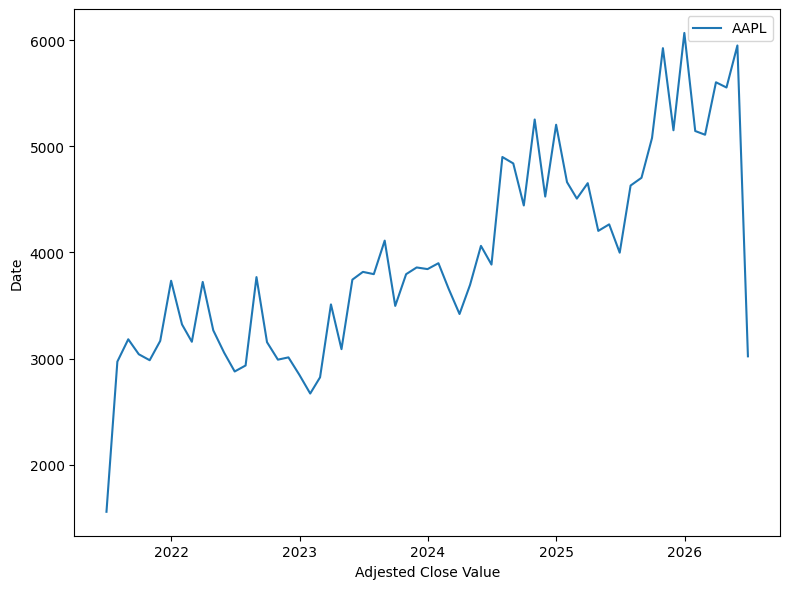

In [48]:
plt.figure(figsize = (8, 6))

plt.plot(monthly_data.index, monthly_data["AAPL"] , label = "AAPL")

plt.xlabel("Adjested Close Value")
plt.ylabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
return_data = Calculations.calculate_returns(portfolio_data)

In [57]:
return_data.tail()

,AAPL,Date_AAPL,MSFT,Date_MSFT,AMZN,Date_AMZN,TSLA,Date_TSLA,GOOGL,Date_GOOGL,...,Rolling Std (AAPL),Rolling Std (MSFT),Rolling Std (AMZN),Rolling Std (TSLA),Rolling Std (GOOGL),Rolling Std (META),Rolling Std (NVDA),Rolling Std (JPM),Rolling Std (WMT),Rolling Std (NFLX)
1250,-0.018872,2026-06-08,-0.011832,2026-06-08,-0.003292,2026-06-08,0.045908,2026-06-08,-0.013576,2026-06-08,...,0.012005,0.022879,0.017230,0.030273,0.019276,0.023183,0.029083,0.013960,0.022470,0.014825
1251,-0.036446,2026-06-09,-0.020231,2026-06-09,-0.004200,2026-06-09,-0.030004,2026-06-09,0.002615,2026-06-09,...,0.014705,0.023292,0.017117,0.029296,0.018355,0.022879,0.028669,0.013833,0.022103,0.014321
1252,0.003545,2026-06-10,-0.014997,2026-06-10,-0.025349,2026-06-10,-0.038041,2026-06-10,-0.021633,2026-06-10,...,0.014628,0.023381,0.017673,0.029863,0.018821,0.023325,0.029636,0.013731,0.021729,0.012930
1253,0.013890,2026-06-11,-0.017667,2026-06-11,0.014748,2026-06-11,0.046018,2026-06-11,0.003900,2026-06-11,...,0.014633,0.023656,0.017582,0.031223,0.015972,0.022567,0.029604,0.013497,0.021552,0.012979
1254,-0.015222,2026-06-12,0.001025,2026-06-12,-0.012256,2026-06-12,0.018239,2026-06-12,0.005339,2026-06-12,...,0.015000,0.023499,0.017609,0.031653,0.016160,0.022514,0.027403,0.014242,0.021476,0.013077
